#### Set up environment and import required libraries

In [1]:
import sys
import numpy as np
import jax
import os
import time

cpu = True
if cpu:
    N = 32
    os.environ['XLA_FLAGS'] = f'--xla_force_host_platform_device_count={N}'

# Import all required libraries
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pandas as pd 
import jax.numpy as jnp
import copy
import optax
import scipy.io as sio
from scipy.io import loadmat
import equinox as eqx
from typing import Tuple
from itertools import product
import joblib
from joblib import Parallel, delayed
from contextlib import contextmanager
from tqdm.auto import tqdm

# Jax enable x64
jax.config.update("jax_enable_x64", True)

# Import from tvboptim
from tvboptim.types import Parameter, BoundedParameter
from tvboptim.types.stateutils import show_parameters
from tvboptim.utils import set_cache_path, cache
from tvboptim.optim.optax import OptaxOptimizer
from tvboptim.optim.callbacks import MultiCallback, DefaultPrintCallback, SavingLossCallback

# Network dynamics imports
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling.base import InstantaneousCoupling
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, FastLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph, DenseGraph
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.data import load_structural_connectivity, load_functional_connectivity
from tvboptim.experimental.network_dynamics.dynamics.base import AbstractDynamics
from tvboptim.experimental.network_dynamics.core.bunch import Bunch

# BOLD monitoring
from tvboptim.observations.tvb_monitors.bold import Bold

# Observation functions
from tvboptim.observations.observation import compute_fc, fc_corr, rmse

# Caching utilities
from tvboptim.utils import set_cache_path, cache

# Set cache path for tvboptim
set_cache_path("ei_tuning")

# Import later built utility functions
from utils import z_score_per_region, lagged_fc_matrices

Cache stored here: c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\cache\ei_tuning


#### Set up data for optimization 

##### Load time-series data

In [2]:
data_dir = './' # data repo
res_dir = './' # results

graph_format = 'png' # graph formatting

# data and model parameters
n_sub = 48

conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

n_nodes = 68 # size of network for AAL90

simu = 0 # set to 1 if simulated data (and not empirical data)

if simu:
    TS_CTR  = np.load("C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBSim\\result\\psilo_baseline_test\\BOLD_g_K_e_8.0714e+00_g_K_i_8.2143e+00_g_Na_e_1.9286e+00_g_Na_i_1.7857e+00_0_60.npy")
    TS_SCZ  = np.load("C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBSim\\result\\psilo_baseline_test\\BOLD_g_K_e_prop_-61.8_g_K_i_prop_-64_g_Na_e_1.9286e+00_g_Na_i_1.7857e+00_0_60.npy")
    # Reshape simulated data to be (subjects, ROIs, time points) like the empirical data
    TS_CTR = np.transpose(TS_CTR, (0, 2, 1))
    TS_SCZ = np.transpose(TS_SCZ, (0, 2, 1))
    print(TS_CTR.shape)
    # Keep only 152 time points to match empirical data
    TS_CTR = TS_CTR[0:48, :, 0:152]
    TS_SCZ= TS_SCZ[0:48, :, 0:152]
    print(TS_CTR.shape)
else:
    TS_CTR  = np.load('TS_Control.npy')
    TS_SCZ  = np.load('TS_Schizo.npy')
    print(TS_CTR.shape)

(116, 82, 152)


##### Organize time-series data

In [3]:
# Separate the participants by condition
condition_0 = TS_CTR[0:n_sub, 0:n_nodes, :]  # all participants (condition 0)
condition_1 = TS_SCZ[:, 0:n_nodes, :]  # Last 48 participants (condition 1)

# Determine the maximum number of participants in either condition (for alignment)
max_participants = max(condition_0.shape[2], condition_1.shape[2])

# Pad the smaller group to match the size of the larger one along the participant dimension
condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

# Stack the conditions along the fourth dimension
new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

##### Get the FC matrix

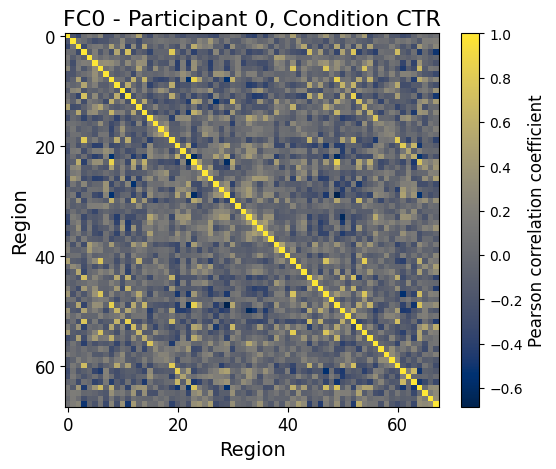

In [4]:
# Compute FC0 for all participants and conditions. shape -> (n_participants, n_conditions, n_regions, n_regions)
fc0 = np.zeros((n_sub, n_cond, n_nodes, n_nodes))
for sub in range(n_sub):
    for cond in range(n_cond):
        fc0[sub, cond] = np.corrcoef(new_array[sub,:,:,cond])

# Choose one participant and condition to visualize
conditions = {0: 'CTR', 1: 'SCZ'}
participant_idx = 0
condition_idx = 0

fc0_test = fc0[participant_idx, condition_idx, :, :]

av = plt.imshow(fc0_test, cmap='cividis')
cbar = plt.colorbar(av, fraction=0.046, pad=0.04)
plt.xticks([0, 20, 40, 60], fontsize=12)
plt.yticks([0, 20, 40, 60], fontsize=12)
plt.title(f"FC0 - Participant {participant_idx}, Condition {conditions[condition_idx]}", fontsize=16)
plt.xlabel("Region", fontsize=14)
plt.ylabel("Region", fontsize=14)
cbar.set_label("Pearson correlation coefficient", fontsize=12)
plt.tight_layout()
plt.show()


### Compute Q0 and Q1 from empirical BOLD signal

**Obs**: We use the notation Q0 and Q1 for the zero lag and 1-TR lag matrices to distinguish from FC0, since they are computed with a different notation. 

We have the formulas for Q0 and Q1 are, respectively:

$$ \hat{S_{ij}}(0) = \frac{1}{T-2} \sum_{1 le T-1} [x_i(t) - (\bar{x_i})][x_j(t) - (\bar{x_j})] $$
$$ \hat{S_{ij}}(1) = \frac{1}{T-2} \sum_{1 le T-1} [x_i(t) - (\bar{x_i})][x_j(t+1) - (\bar{x_j})]$$

In [5]:
# Get empirical time series of interest 
ts = new_array[participant_idx,:,:,condition_idx]
# Take the transpose for the lagged FC matrices computation
X_emp = ts.T
print("Empirical time series shape (time points x regions):", X_emp.shape)

# Z-score the empirical time series per region
z_scored_emp = z_score_per_region(X_emp)

# Compute empirical lagged FC matrices
Q_emp = lagged_fc_matrices(z_scored_emp, n_tau=2, diag_zero=True)
Q0_emp = Q_emp[0]  # FC0 (zero-lag)
Q1_emp = Q_emp[1]  # FC1 (lag-1)

Empirical time series shape (time points x regions): (152, 68)


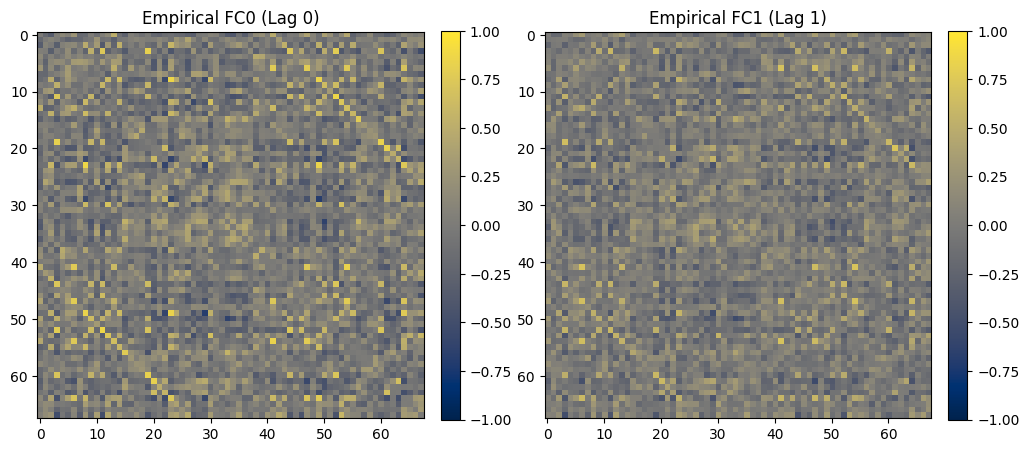

In [6]:
# Plot FC 0 and FC 1 for both empirical and simulated data
fig, axes = plt.subplots(1,2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0].imshow(Q0_emp, vmin=-1, vmax=1, cmap='cividis')
axes[0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1].imshow(Q1_emp, vmin=-1, vmax=1, cmap='cividis')
axes[1].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

##### Load structural connectivity data

In [7]:
# Weights
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
weights = SCR / np.max(SCR)
n_nodes = weights.shape[0]

# Delays
lengths = pd.read_csv('tract_lengths.csv')
speed = 3.0
delays = lengths / speed

# Load empirical functional connectivity as optimization target
fc_target = fc0_test
# Set target FC diagonal to zero to ignore diagonal (self-connections) during loss calculation
fc_target = jnp.fill_diagonal(fc_target, 0.0, inplace=False)

# Load region labels and coordinates
df = pd.read_csv(
    'centers.txt',
    sep='\t',
    header=None,
    dtype={1: float, 2: float, 3: float},
    names=['label', 'x', 'y', 'z']
)

labels = df['label'].tolist()
coords = df[['x','y','z']].values

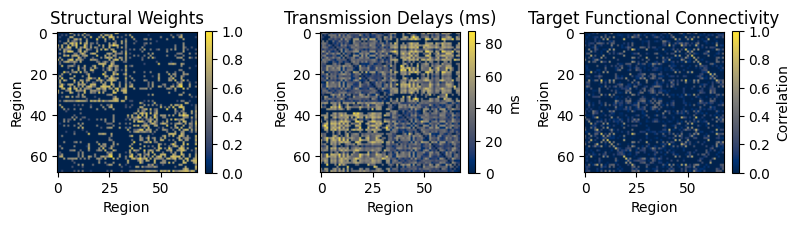

In [8]:
# Plot for visualization

# Define consistent color palette derived from cividis
cividis_cmap = plt.cm.cividis
cividis_colors = cividis_cmap(np.linspace(0, 1, 256))
accent_blue = cividis_cmap(0.3)  # Dark blue from cividis
accent_gold = cividis_cmap(0.85)  # Gold/yellow from cividis
accent_mid = cividis_cmap(0.6)   # Mid-tone

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8.1, 4))

# Structural weights - use cividis
im1 = ax1.imshow(weights, cmap='cividis', vmin=0, vmax=1)
ax1.set_title('Structural Weights')
ax1.set_xlabel('Region')
ax1.set_ylabel('Region')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Delays - use cividis
im2 = ax2.imshow(delays, cmap='cividis')
ax2.set_title('Transmission Delays (ms)')
ax2.set_xlabel('Region')
ax2.set_ylabel('Region')
plt.colorbar(im2, ax=ax2, fraction=0.046, label='ms')

# Target FC - use cividis
im3 = ax3.imshow(fc_target, vmin=0, vmax=1.0, cmap='cividis')
ax3.set_title('Target Functional Connectivity')
ax3.set_xlabel('Region')
ax3.set_ylabel('Region')
plt.colorbar(im3, ax=ax3, label='Correlation', fraction=0.046)

plt.tight_layout()
plt.show()

#### Define the model to optimize

In [9]:
class ReducedWongWangEIB(AbstractDynamics):
    """Two-population Reduced Wong-Wang model with E-I balance support"""

    STATE_NAMES = ('S_e', 'S_i')
    INITIAL_STATE = (0.001, 0.001)
    AUXILIARY_NAMES = ('H_e', 'H_i')
    g_prop = 0  # awake

    DEFAULT_PARAMS = Bunch(
        # Excitatory population parameters
        a_e=310.0,         # Input gain parameter
        b_e=125.0,         # Input shift parameter [Hz]
        d_e=0.160,         # Input scaling parameter [s]
        gamma_e=0.641/1000,  # Kinetic parameter
        tau_e=100.0,       # NMDA decay time constant [ms]
        w_p   = 1.4 * (1 - 0.2*g_prop),           # Excitatory recurrence weight
        W_e=1.0,           # External input scaling weight

        # Inhibitory population parameters
        a_i=615.0,         # Input gain parameter
        b_i=177.0,         # Input shift parameter [Hz]
        d_i=0.087,         # Input scaling parameter [s]
        gamma_i=1.0/1000,  # Kinetic parameter
        tau_i = 10  * (1 + 0.8*g_prop),        # NMDA decay time constant [ms]
        W_i=0.7,           # External input scaling weight

        # Synaptic weights
        J_N=0.15,          # NMDA current [nA]
        J_i   = 1.0 * (1 + 0.6*g_prop),          # Inhibitory synaptic weight

        # External inputs
        I_o=0.382,         # Background input current
        I_ext=0.0,         # External stimulation current

        # Coupling parameters
        lamda=1.0,         # Lambda: inhibitory coupling scaling

    )

# Primary GABA effect
#J_i = 1.0 → 1.4
# Slower inhibition
#tau_i = 10.0 → 18.0
# Slightly reduced excitation
#w_p = 1.4 → 1.2

    COUPLING_INPUTS = {
        'coupling': 2,  # Long-range excitation and Feedforward inhibition
    }

    def dynamics(
        self,
        t: float,
        state: jnp.ndarray,
        params: Bunch,
        coupling: Bunch,
        external: Bunch
    ) -> Tuple[jnp.ndarray, jnp.ndarray]:
        """Compute two-population Wong-Wang dynamics with dual coupling."""

        # Unpack state variables
        S_e = state[0]  # Excitatory synaptic gating
        S_i = state[1]  # Inhibitory synaptic gating

        # Unpack coupling inputs
        c_lre = params.J_N * coupling.coupling[0]  # Long-range excitation
        c_ffi = params.J_N * coupling.coupling[1]  # Feedforward inhibition

        # Excitatory population input
        J_N_S_e = params.J_N * S_e
        x_e_pre = (params.w_p * J_N_S_e - params.J_i * S_i +
                   params.W_e * params.I_o + c_lre + params.I_ext)

        # Excitatory transfer function
        x_e = params.a_e * x_e_pre - params.b_e
        H_e = x_e / (1.0 - jnp.exp(-params.d_e * x_e))

        # Excitatory dynamics
        dS_e_dt = -(S_e / params.tau_e) + (1.0 - S_e) * H_e * params.gamma_e

        # Inhibitory population input
        x_i_pre = J_N_S_e - S_i + params.W_i * params.I_o + params.lamda * c_ffi

        # Inhibitory transfer function
        x_i = params.a_i * x_i_pre - params.b_i
        H_i = x_i / (1.0 - jnp.exp(-params.d_i * x_i))

        # Inhibitory dynamics
        dS_i_dt = -(S_i / params.tau_i) + H_i * params.gamma_i

        # Package results
        derivatives = jnp.array([dS_e_dt, dS_i_dt])
        auxiliaries = jnp.array([H_e, H_i])

        return derivatives, auxiliaries
    
class EIBLinearCoupling(InstantaneousCoupling):
    """EIB Linear coupling with separate excitatory and inhibitory weight matrices.

    This coupling produces two outputs:
        c_lre: Long-range excitation (wLRE * S_e)
        c_ffi: Feedforward inhibition (wFFI * S_e)

    Both couplings are driven by the excitatory activity (S_e) from other regions.
    """

    N_OUTPUT_STATES = 2  # Produces two coupling outputs

    DEFAULT_PARAMS = Bunch(
        wLRE = 1.0,  # Long-range excitation weight matrix
        wFFI = 1.0,  # Feedforward inhibition weight matrix
    )

    def pre(
        self,
        incoming_states: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Pre-synaptic transformation: multiply S_e with wLRE and wFFI."""
        # incoming_states[0] is S_e from all source nodes
        S_e = incoming_states[0]  # [n_target, n_source]
        # Apply weights: element-wise multiply S_e with each weight matrix
        # params.wLRE and params.wFFI have shape [n_nodes, n_nodes]
        c_lre = S_e * params.wLRE  # [n_target, n_source]
        c_ffi = S_e * params.wFFI  # [n_target, n_source]

        # Stack into [2, n_target, n_source]
        return jnp.stack([c_lre, c_ffi], axis=0)

    def post(
        self,
        summed_inputs: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Post-synaptic transformation: pass through without scaling."""
        return summed_inputs
    

#### Building the network model

In [10]:
# Create network components
graph = DenseGraph(weights, region_labels=labels)
dynamics = ReducedWongWangEIB(J_i = jnp.ones((n_nodes)))

# Initialize EIB coupling with dual weight matrices
# wLRE and wFFI start as copies of structural connectivity
coupling = EIBLinearCoupling(incoming_states=["S_e"])

# Set the weight matrices to the proper shape based on structural connectivity
# Both start as scaled versions of structural connectivity
coupling.params.wLRE = jnp.ones((n_nodes, n_nodes)) #+ 0.8*fc_target  # [n_nodes, n_nodes]
coupling.params.wFFI = jnp.ones((n_nodes, n_nodes)) #- 0.8*fc_target  # [n_nodes, n_nodes]

# Small noise to break symmetry
noise = AdditiveNoise(sigma=0.01, apply_to="S_e")

# Assemble the network
network = Network(
    dynamics=dynamics,
    coupling={'coupling': coupling},  # Both use same coupling but produce different outputs
    graph=graph,
    noise=noise
)

print(f"Network created with {n_nodes} nodes")

Network created with 68 nodes


#### Initial simulation

In [11]:
# Prepare simulation: compile model and initialize state
t1 = 314_000   # Simulation duration (ms) - 1 minute for initial transient
dt = 4.0      # Integration timestep (ms) matching original script
solver = BoundedSolver(Heun(), low=0.0, high=1.0)
model, state = prepare(network, solver, t1=t1, dt=dt)

# Run initial transient to reach quasi-stationary state
print("Running initial transient simulation...")
result_init = jax.block_until_ready(model(state))

# Update network with final state as new initial conditions
network.update_history(result_init)

# Prepare for shorter simulations used in EI tuning
bold_TR = 2000.0
model_short, state_short = prepare(network, solver, t1=bold_TR, dt=dt)

print(f"Initial simulation complete. Final S_e mean: {result_init.data[-1, 0, :].mean():.3f}")
print(f"Initial simulation complete. Final S_i mean: {result_init.data[-1, 1, :].mean():.3f}")


Running initial transient simulation...
Initial simulation complete. Final S_e mean: 0.856
Initial simulation complete. Final S_i mean: 0.949


#### Create BOLD monitor for evaluation

In [12]:
# Create BOLD monitor - we'll monitor S_e (first state variable)
# The BOLD period is bold_TR
bold_monitor = Bold(
    period=bold_TR,           # BOLD sampling period (TR = 2000 ms)
    downsample_period=4.0,  # Intermediate downsampling matches dt
    voi=0,                  # Monitor first state variable (S_e)
    history=result_init     # Use initial state as warm start for BOLD history
)

print("BOLD monitor initialized")

BOLD monitor initialized


#### Utility functions

In [13]:
# Will be populated after initial simulation completes
model_eval, state_eval, _state = None, None, None

def setup_eval_model():
    """Setup evaluation model for FC computation (called after initial simulation)."""
    global model_eval, state_eval, _state
    model_eval, state_eval = prepare(network, Heun(), t1=t1, dt=dt)
    _state = copy.deepcopy(state_eval)

def eval_fc(J_i, wLRE, wFFI):
    """Evaluate FC for given parameters using a long simulation."""
    _state.dynamics.J_i = J_i
    _state.coupling.coupling.wLRE = wLRE
    _state.coupling.coupling.wFFI = wFFI

    # Run simulation
    raw_result = model_eval(_state)

    # Compute BOLD
    bold_signal = bold_monitor(raw_result)

    # Compute FC (skip initial transient)
    fc = compute_fc(bold_signal, skip_t=20)
    return fc

#### Gradient-based optimization approach

In [14]:
# Prepare simulation
t1_opt = 314_000 # Simulation duration (ms) 
dt_opt = 4.0
solver_opt = BoundedSolver(Heun(), low=0.0, high=1.0)
model_opt, state_opt = prepare(network, solver_opt, t1=t1_opt, dt=dt_opt)

# FIC tuning parameter
target_fic = 0.25  # Target excitatory activity level

# Create BOLD monitor
bold_monitor_opt = Bold(
    period=bold_TR,
    downsample_period=4.0,
    voi=0,
    history=result_init
)

print("Optimization model prepared")

# Define loss function for optimization

def loss(state, verbose=False):
    """Combined loss function for FC matching and E-I balance"""
    # Simulate neural dynamics
    ts = model_opt(state)

    # Compute BOLD signal from simulated activity
    bold = bold_monitor_opt(ts)

    ## NEW
    bold_signal = bold.data
    # Reshape from (time points, 1, regions) to (time points, regions) 
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    # Remove transient (first 5 time points)
    bold_signal = bold_signal[5:, :]
    # Z-score the BOLD signal per region
    z_scored_bold = z_score_per_region(bold_signal)

    # Compute simulated lagged FC matrices
    Qsim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim = Qsim[0]  # Simulated FC0
    Q1_sim = Qsim[1]  # Simulated FC1

    if verbose:
        print("Simulated BOLD signal shape (time points x regions):", z_scored_bold.shape)
        print(f"Simulated F0 shape: {Q0_sim.shape}, F1 shape: {Q1_sim.shape}")
        print(f"Empirical F0 shape: {Q0_emp.shape}, F1 shape: {Q1_emp.shape}")
    
    # Loss component 1: FC discrepancy with empirical data
    # empirical Q0/Q1 already computed (Q0_emp, Q1_emp)
    loss_q0 = rmse(Q0_sim, Q0_emp)
    loss_q1 = rmse(Q1_sim, Q1_emp)

    # Loss component 2: Feedback inhibition control
    # Penalize deviation from target excitatory activity level
    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)  # Mean S_e over final timesteps
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    # Combined loss (both terms have similar scales)
    return loss_q0 + loss_q1 + activity_loss

# Evaluate initial loss
initial_loss = loss(state_opt)
print(f"Initial loss: {initial_loss:.4f}")

# Mark parameters for optimization (J_i, wLRE, wFFI) with appropriate constraints
state_opt.dynamics.J_i = Parameter(state_opt.dynamics.J_i)
state_opt.coupling.coupling.wLRE = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)
state_opt.coupling.coupling.wFFI = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)

# Define gradient optimization function 
@cache("gradient_optimization", redo=True)
def run_gradient_optimization(
    max_steps: int,
    learning_rate: float,
    lr_schedule: str = "constant",
    cosine_alpha: float = 0.0,
    cosine_decay_steps: int | None = 40,
    verbose: bool = True,
):
    """Run gradient-based optimization with optional LR scheduling.

    Parameters
    ----------
    max_steps : int
        Number of optimization steps.
    learning_rate : float
        Initial learning rate.
    lr_schedule : str
        "constant" or "cosine".
    cosine_alpha : float
        Final LR fraction for cosine decay (0.0 means decays to 0).
    cosine_decay_steps : int or None
        Number of decay steps for cosine schedule. If None, uses max_steps.
    verbose : bool
        Whether to print schedule information.
    """

    # Choose learning rate: fixed scalar or cosine-decay schedule
    if lr_schedule == "cosine":
        decay_steps = max_steps if cosine_decay_steps is None else int(cosine_decay_steps)
        lr = optax.cosine_decay_schedule(
            init_value=learning_rate,
            decay_steps=decay_steps,
            alpha=cosine_alpha,
        )
        if verbose:
            print(
                f"Using cosine LR: init={learning_rate}, decay_steps={decay_steps}, alpha={cosine_alpha}"
            )
    elif lr_schedule == "constant":
        lr = learning_rate
        if verbose:
            print(f"Using constant LR: {learning_rate}")
    else:
        raise ValueError("lr_schedule must be 'constant' or 'cosine'")

    # Create optimizer
    optimizer = OptaxOptimizer(
        loss,
        optax.adamaxw(learning_rate=lr),
        callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
    )

    # Run optimization
    opt_state, opt_fitting_data = optimizer.run(state_opt, max_steps=max_steps)

    return opt_state, opt_fitting_data

def compute_fc_from_state(opt_state):
    """Compute FC from a given optimization state."""
    return eval_fc(
        opt_state.dynamics.J_i,
        opt_state.coupling.coupling.wLRE,
        opt_state.coupling.coupling.wFFI
    )

def evaluate_trial(opt_state):
    """ Evaluate a single trial and return metrics."""
    fc_opt = compute_fc_from_state(opt_state)

    # Compute quality metrics
    corr_val = fc_corr(fc_opt, fc_target)
    rmse_val = rmse(fc_opt, fc_target)
    return {
        "corr": float(jnp.nan_to_num(corr_val, nan=-jnp.inf)),
        "rmse": float(jnp.nan_to_num(rmse_val, nan=jnp.inf)),
    }

def evaluate_trial_grid(lr: float, steps: int, verbose=False):
    """ Evaluate a single trial with given hyperparameters and return metrics. To use when running a grid search. """
    opt_state, _ = run_gradient_optimization(learning_rate=lr, max_steps=steps)
    evaluate_dict = evaluate_trial(opt_state)
    if verbose:
        print(f"Trial (lr={lr:.4f}, steps={steps}): corr={evaluate_dict['corr']:.4f}, rmse={evaluate_dict['rmse']:.4f}")
    evaluate_dict.update({ "lr": lr, "steps": steps })
    return evaluate_dict

#  Setup evaluation model
setup_eval_model()

# Compute FC before gradient descent optimization
print("Computing pre-gradient descent functional connectivity...")

fc_pre_gd, fc_corr_pre, fc_rmse_pre = compute_fc_from_state(state_opt), evaluate_trial(state_opt)["corr"], evaluate_trial(state_opt)["rmse"]

Optimization model prepared
Initial loss: 0.8207
Computing pre-gradient descent functional connectivity...


##### Set parameters for gradient descent

In [15]:
# Hyperparameters
max_steps = 120
learning_rate = 0.0325

##### Run gradient optimization

In [16]:
optimized_state, fitting_data = run_gradient_optimization(max_steps = max_steps, learning_rate = learning_rate)

Running computations for gradient_optimization
Using constant LR: 0.0325
Step 0: 0.820654
Step 1: 0.788900
Step 2: 0.747729
Step 3: 0.691444
Step 4: 0.621042
Step 5: 0.545253
Step 6: 0.468884
Step 7: 0.455154
Step 8: 0.458920
Step 9: 0.465686
Step 10: 0.467640
Step 11: 0.468637
Step 12: 0.468778
Step 13: 0.468177
Step 14: 0.467850
Step 15: 0.467258
Step 16: 0.466695
Step 17: 0.466445
Step 18: 0.465611
Step 19: 0.464921
Step 20: 0.464050
Step 21: 0.463084
Step 22: 0.462000
Step 23: 0.460858
Step 24: 0.459590
Step 25: 0.458430
Step 26: 0.457006
Step 27: 0.455660
Step 28: 0.454208
Step 29: 0.452662
Step 30: 0.451331
Step 31: 0.449241
Step 32: 0.447016
Step 33: 0.444894
Step 34: 0.442422
Step 35: 0.439988
Step 36: 0.437148
Step 37: 0.432582
Step 38: 0.428054
Step 39: 0.422929
Step 40: 0.420918
Step 41: 0.421775
Step 42: 0.419520
Step 43: 0.414684
Step 44: 0.407881
Step 45: 0.408312
Step 46: 0.404499
Step 47: 0.401467
Step 48: 0.393982
Step 49: 0.392049
Step 50: 0.390295
Step 51: 0.385358
S

In [17]:
fc_opt = compute_fc_from_state(optimized_state)
fc_corr_opt = evaluate_trial(optimized_state)['corr']
fc_rmse_opt = evaluate_trial(optimized_state)['rmse']

print(f"\nOptimization Results:")
print(f"  Pre-Optimization  - Correlation: {fc_corr_pre:.4f}, RMSE: {fc_rmse_pre:.4f}")
print(f"  Post-Optimization - Correlation: {fc_corr_opt:.4f}, RMSE: {fc_rmse_opt:.4f}")
print(f"  Improvement: Δcorr = {fc_corr_opt - fc_corr_pre:+.4f}, ΔRMSE = {fc_rmse_opt - fc_rmse_pre:+.4f}")


Optimization Results:
  Pre-Optimization  - Correlation: 0.0175, RMSE: 0.2435
  Post-Optimization - Correlation: 0.8669, RMSE: 0.1264
  Improvement: Δcorr = +0.8494, ΔRMSE = -0.1170


##### Plot results

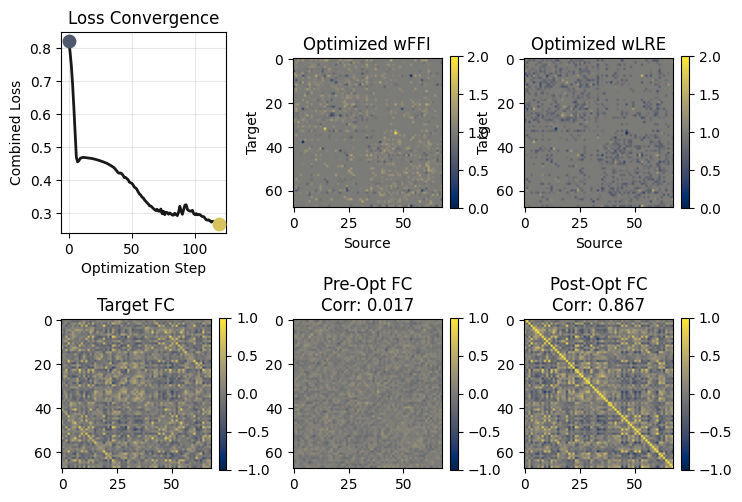

In [18]:
# Extract loss values
loss_values = fitting_data["loss"].save
n_steps = len(loss_values)

fig = plt.figure(figsize=(8.1, 6))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.4)

# Top left: Loss trajectory - use cividis-derived colors
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(loss_values, linewidth=2, color="k", alpha=0.9)
ax1.scatter(0, loss_values[0], s=80, color=accent_blue, zorder=5)
ax1.scatter(n_steps-1, loss_values.array[-1], s=80, color=accent_gold, zorder=5)
ax1.set_xlabel('Optimization Step')
ax1.set_ylabel('Combined Loss')
ax1.set_title('Loss Convergence')
ax1.grid(True, alpha=0.3)

# Top middle: wFFI matrix - use cividis
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(optimized_state.coupling.coupling.wFFI, vmin=0, vmax=2, cmap='cividis')
ax2.set_title('Optimized wFFI')
ax2.set_xlabel('Source')
ax2.set_ylabel('Target')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Top right: wLRE matrix - use cividis
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(optimized_state.coupling.coupling.wLRE, vmin=0, vmax=2, cmap='cividis')
ax3.set_title('Optimized wLRE')
ax3.set_xlabel('Source')
ax3.set_ylabel('Target')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# Bottom row: FC comparison - use cividis
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(fc_target, vmin=-1, vmax=1.0, cmap='cividis')
ax4.set_title('Target FC')
plt.colorbar(im4, ax=ax4, fraction=0.046)

ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(fc_pre_gd, vmin=-1, vmax=1.0, cmap='cividis')
ax5.set_title(f'Pre-Opt FC\nCorr: {fc_corr_pre:.3f}')
plt.colorbar(im5, ax=ax5, fraction=0.046)

ax6 = fig.add_subplot(gs[1, 2])
im6 = ax6.imshow(fc_opt + np.eye(fc_opt.shape[0]), vmin=-1, vmax=1.0, cmap='cividis')
ax6.set_title(f'Post-Opt FC\nCorr: {fc_corr_opt:.3f}')
plt.colorbar(im6, ax=ax6, fraction=0.046)

plt.show()

### Test

In [21]:
# Single loss with heavier FC1
beta_fc1 = 2.0   # try 1.0, 2.0, 3.0
alpha_fc0 = 1.0

def loss(state):
    ts = model_opt(state)
    bold = bold_monitor_opt(ts)

    bold_signal = bold.data
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    bold_signal = bold_signal[5:, :]
    z_scored_bold = z_score_per_region(bold_signal)

    Qsim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim, Q1_sim = Qsim[0], Qsim[1]

    loss_q0 = rmse(Q0_sim, Q0_emp)
    loss_q1 = rmse(Q1_sim, Q1_emp)

    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    return alpha_fc0 * loss_q0 + beta_fc1 * loss_q1 + activity_loss

In [22]:
optimizer_test = OptaxOptimizer(
    loss,
    optax.adamaxw(learning_rate=learning_rate),
    callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
)

optimized_state, optimized_fit = optimizer_test.run(state_opt, max_steps=max_steps)

Step 0: 1.022387
Step 1: 0.990873
Step 2: 0.949785
Step 3: 0.894931
Step 4: 0.824909
Step 5: 0.748729
Step 6: 0.671743
Step 7: 0.657772
Step 8: 0.660105
Step 9: 0.666513
Step 10: 0.668386
Step 11: 0.670046
Step 12: 0.670178
Step 13: 0.670381
Step 14: 0.670262
Step 15: 0.670172
Step 16: 0.669604
Step 17: 0.668612
Step 18: 0.668425
Step 19: 0.667949
Step 20: 0.667205
Step 21: 0.666343
Step 22: 0.665203
Step 23: 0.664011
Step 24: 0.661765
Step 25: 0.660532
Step 26: 0.659364
Step 27: 0.658682
Step 28: 0.658121
Step 29: 0.655692
Step 30: 0.654133
Step 31: 0.652528
Step 32: 0.650627
Step 33: 0.648125
Step 34: 0.645880
Step 35: 0.642598
Step 36: 0.639658
Step 37: 0.636298
Step 38: 0.633868
Step 39: 0.629776
Step 40: 0.623735
Step 41: 0.619604
Step 42: 0.614332
Step 43: 0.607345
Step 44: 0.602240
Step 45: 0.597324
Step 46: 0.591056
Step 47: 0.585471
Step 48: 0.576945
Step 49: 0.572827
Step 50: 0.565463
Step 51: 0.560036
Step 52: 0.548510
Step 53: 0.542382
Step 54: 0.536475
Step 55: 0.528760
St

### End of test

### Compute Q0 and Q1 from empirical and simulated time-series data

**Obs**: We use the notation Q0 and Q1 for the zero lag and 1-TR lag matrices to distinguish from FC0, since they are computed with a different notation. 

We have the formulas for Q0 and Q1 are, respectively:

$$ \hat{S_{ij}}(0) = \frac{1}{T-2} \sum_{1 le T-1} [x_i(t) - (\bar{x_i})][x_j(t) - (\bar{x_j})] $$
$$ \hat{S_{ij}}(1) = \frac{1}{T-2} \sum_{1 le T-1} [x_i(t) - (\bar{x_i})][x_j(t+1) - (\bar{x_j})]$$

In [23]:
transient_lim = 5  # Number of initial time points to remove from BOLD signal

# get simulated time series
raw_result_gd = model_opt(optimized_state)
bold_result_gd = bold_monitor_opt(raw_result_gd)
bold_signal_gd = bold_result_gd.data
# Reshape from (time points, 1, regions) to (time points, regions) 
n_timepoints_gd, n_nodes_gd = bold_signal_gd.shape[0], bold_signal_gd.shape[-1]
bold_signal_gd = bold_signal_gd.reshape(n_timepoints_gd, n_nodes_gd)
# Remove transient
bold_signal_gd = bold_signal_gd[transient_lim:, :]
print("Simulated BOLD signal shape:", bold_signal_gd.shape)

Simulated BOLD signal shape: (152, 68)


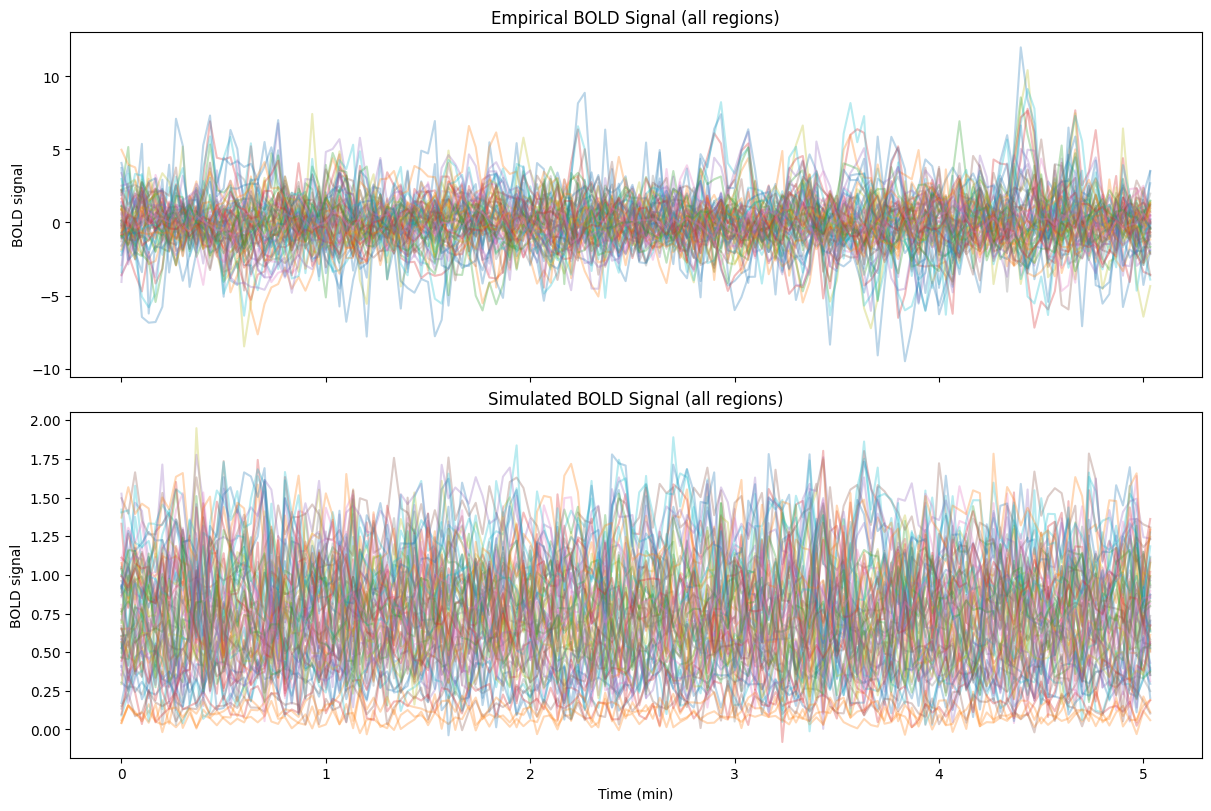

In [24]:
# Plot bold signal for empirical and simulated data
time_gd = np.arange(bold_signal_gd.shape[0]) * bold_TR / (1e3*60)
time_emp = np.arange(X_emp.shape[0]) * bold_TR / (1e3*60)

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                            sharex=True, constrained_layout=True)

axes[0].plot(time_emp, X_emp, alpha=0.3)
axes[0].set_title("Empirical BOLD Signal (all regions)")
axes[0].set_ylabel("BOLD signal")

axes[1].plot(time_gd, bold_signal_gd, alpha=0.3)
axes[1].set_title("Simulated BOLD Signal (all regions)")
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("BOLD signal")
plt.show()

In [25]:
z_scored_emp = z_score_per_region(X_emp)
z_scored_gd = z_score_per_region(bold_signal_gd)

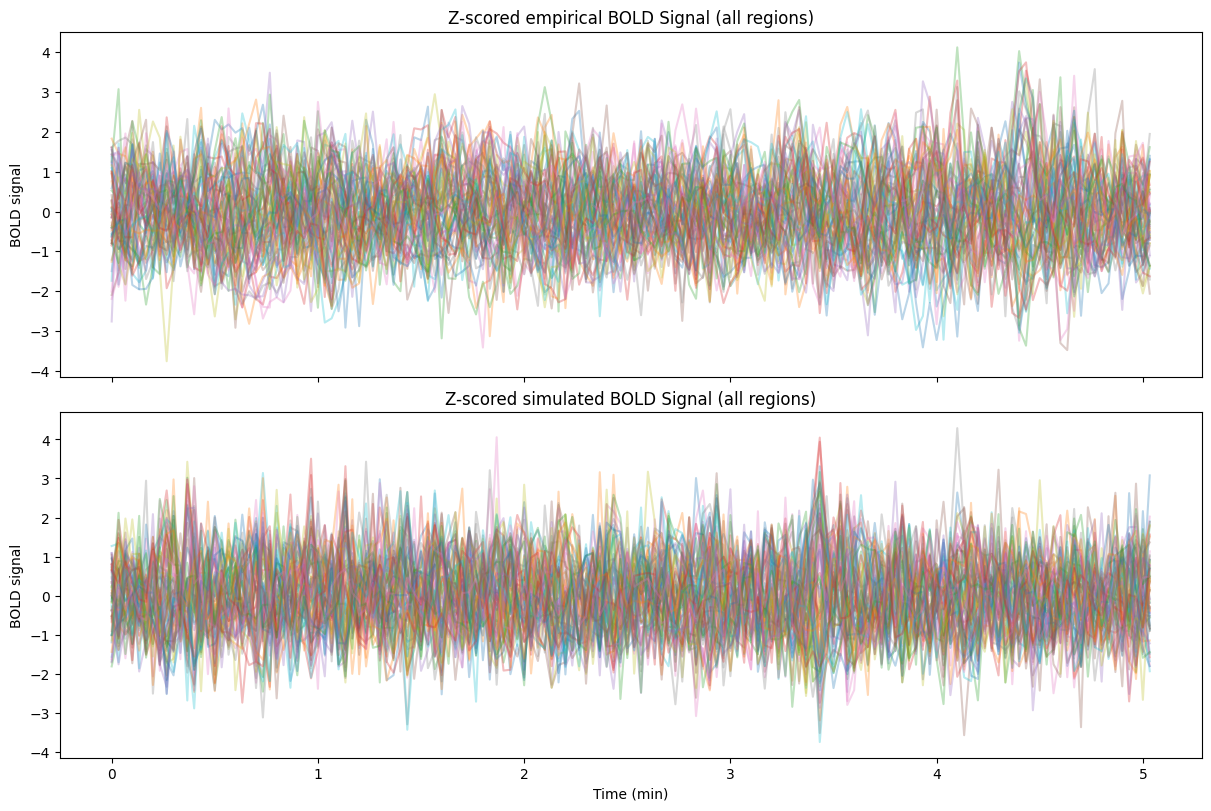

In [26]:
time_emp = np.arange(z_scored_emp.shape[0]) * bold_TR / (1e3*60)
time_gd = np.arange(z_scored_gd.shape[0]) * bold_TR / (1e3*60)

# Plot bold signal for empirical and simulated data
fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                            sharex=True, constrained_layout=True)

axes[0].plot(time_emp, z_scored_emp, alpha=0.3)
axes[0].set_title("Z-scored empirical BOLD Signal (all regions)")
axes[0].set_ylabel("BOLD signal")

axes[1].plot(time_gd, z_scored_gd, alpha=0.3)
axes[1].set_title("Z-scored simulated BOLD Signal (all regions)")
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("BOLD signal")
plt.show()

In [27]:
# Compute empirical lagged FC matrices
Q_emp = lagged_fc_matrices(z_scored_emp, n_tau=2, diag_zero=True)
Q_emp_0 = Q_emp[0]  # FC0 (zero-lag)
Q_emp_1 = Q_emp[1]  # FC1 (lag-1)

# Compute simulated lagged FC matrices
Q_sim = lagged_fc_matrices(z_scored_gd, n_tau=2, diag_zero=True)
Q_sim_0 = Q_sim[0]  # Simulated FC0
Q_sim_1 = Q_sim[1]  # Simulated FC1

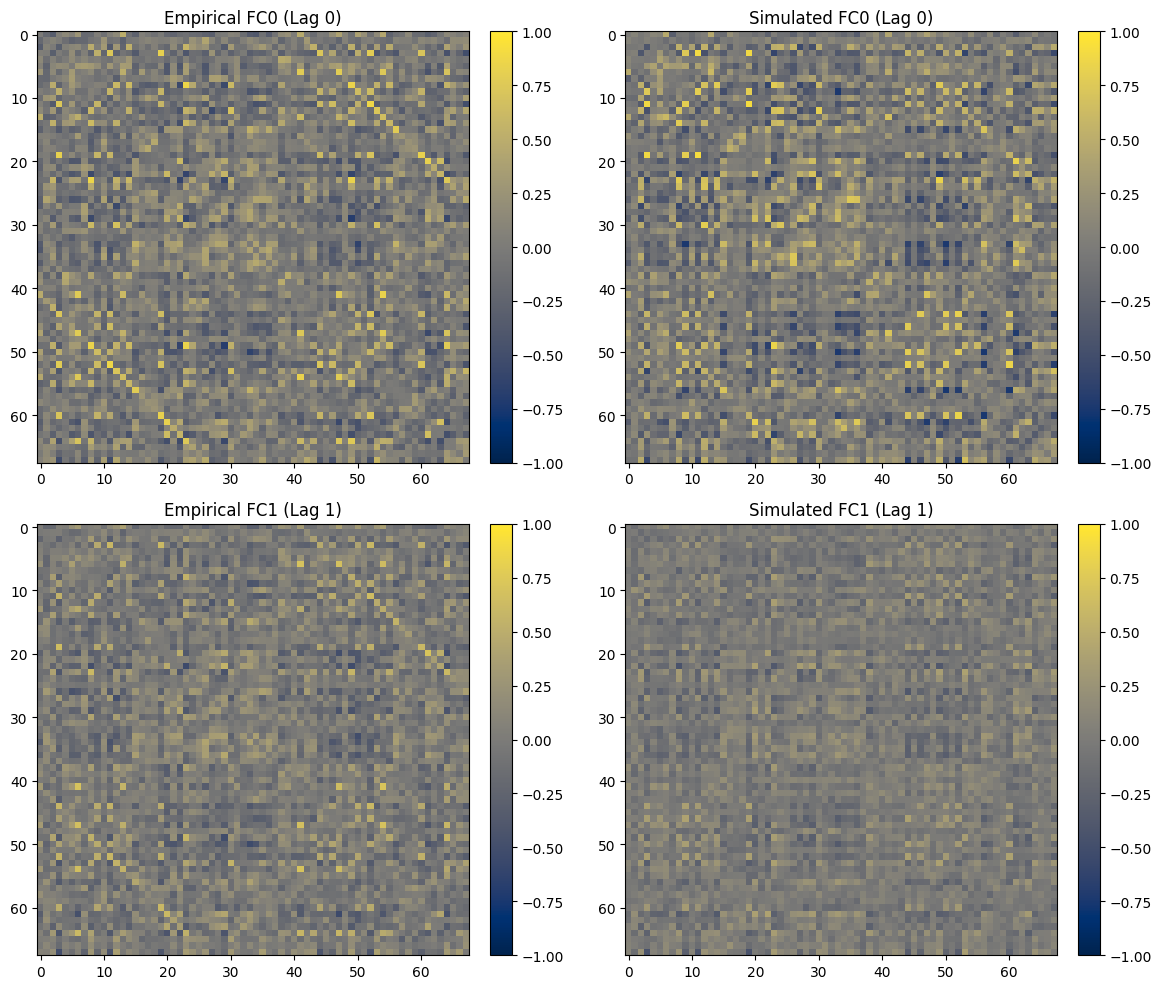

In [28]:
# Plot FC 0 and FC 1 for both empirical and simulated data
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0, 0].imshow(Q_emp_0, vmin=-1, vmax=1, cmap='cividis')
axes[0, 0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
# FC0 - Simulated
im1 = axes[0, 1].imshow(Q_sim_0, vmin=-1, vmax=1, cmap='cividis')
axes[0, 1].set_title('Simulated FC0 (Lag 0)')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1, 0].imshow(Q_emp_1, vmin=-1, vmax=1, cmap='cividis')
axes[1, 0].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)
# FC1 - Simulated
im3 = axes[1, 1].imshow(Q_sim_1, vmin=-1, vmax=1, cmap='cividis')
axes[1, 1].set_title('Simulated FC1 (Lag 1)')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [29]:
fc0_corr = fc_corr(Q_sim_0, Q_emp_0)
fc1_corr = fc_corr(Q_sim_1, Q_emp_1)

In [30]:
print(f"FC0 (zero-lag) correlation: {fc0_corr:.4f}")
print(f"FC1 (lag-1) correlation: {fc1_corr:.4f}")

FC0 (zero-lag) correlation: 0.8706
FC1 (lag-1) correlation: 0.7680


#### Test 2

In [ ]:
# ---- Two-stage schedule (copy/paste) ----

# Stage 1: fit FC0 only
beta_fc1 = 0.5
max_steps_stage1 = 120
learning_rate_stage1 = 0.0325

def loss_stage1(state):
    ts = model_opt(state)
    bold = bold_monitor_opt(ts)

    bold_signal = bold.data
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    bold_signal = bold_signal[5:, :]
    z_scored_bold = z_score_per_region(bold_signal)

    Qsim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim, Q1_sim = Qsim[0], Qsim[1]

    loss_q0 = rmse(Q0_sim, Q0_emp)
    loss_q1 = rmse(Q1_sim, Q1_emp)

    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    return loss_q0 + beta_fc1 * loss_q1 + activity_loss

optimizer_stage1 = OptaxOptimizer(
    loss_stage1,
    optax.adamaxw(learning_rate=learning_rate_stage1),
    callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
)

opt_state_stage1, fit_stage1 = optimizer_stage1.run(state_opt, max_steps=max_steps_stage1)

# Stage 2: start from Stage 1 params, add FC1
max_steps_stage2 = 120
learning_rate_stage2 = 0.0325

def loss_stage2(state):
    ts = model_opt(state)
    bold = bold_monitor_opt(ts)

    bold_signal = bold.data
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    bold_signal = bold_signal[5:, :]
    z_scored_bold = z_score_per_region(bold_signal)

    Qsim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim, Q1_sim = Qsim[0], Qsim[1]

    loss_q0 = rmse(Q0_sim, Q0_emp)
    loss_q1 = rmse(Q1_sim, Q1_emp)

    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    # ramp FC1 weight from 0.2 -> 1.0 over stage 2 steps
    return loss_q0 + loss_q1 + activity_loss

optimizer_stage2 = OptaxOptimizer(
    loss_stage2,
    optax.adamaxw(learning_rate=learning_rate_stage2),
    callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
)

opt_state_stage2, fit_stage2 = optimizer_stage2.run(opt_state_stage1, max_steps=max_steps_stage2)

optimized_state = opt_state_stage2

Step 0: 0.719787
Step 1: 0.687982
Step 2: 0.646760
Step 3: 0.590657
Step 4: 0.520953
Step 5: 0.445315
Step 6: 0.368069
Step 7: 0.354186
Step 8: 0.360659
Step 9: 0.367256
Step 10: 0.370126
Step 11: 0.371543
Step 12: 0.372360
Step 13: 0.372808
Step 14: 0.373092
Step 15: 0.373189
Step 16: 0.373196
Step 17: 0.373129
Step 18: 0.373003
Step 19: 0.372819
Step 20: 0.372584
Step 21: 0.372309
Step 22: 0.371971
Step 23: 0.371602
Step 24: 0.371202
Step 25: 0.370746
Step 26: 0.370246
Step 27: 0.369717
Step 28: 0.369149
Step 29: 0.368529
Step 30: 0.367867
Step 31: 0.367150
Step 32: 0.366380
Step 33: 0.365521
Step 34: 0.364775
Step 35: 0.363986
Step 36: 0.363270
Step 37: 0.362671
Step 38: 0.361889
Step 39: 0.361161
Step 40: 0.360330
Step 41: 0.359261
Step 42: 0.358409
Step 43: 0.357270
Step 44: 0.356141
Step 45: 0.354745
Step 46: 0.352977
Step 47: 0.351045
Step 48: 0.348777
Step 49: 0.346378
Step 50: 0.343668
Step 51: 0.341056
Step 52: 0.338698
Step 53: 0.336563
Step 54: 0.334115
Step 55: 0.331697
St

KeyboardInterrupt: 